<a href="https://colab.research.google.com/github/elenasofia98/Artificial-Intelligence-and-Cybersecurity/blob/main/MIA_Shokri_2016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision scikit-learn tqdm numpy

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset

import torchvision
import torchvision.transforms as transforms

In [3]:
SEED = 42

def set_seed(seed=42):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

set_seed(SEED)

In [4]:
def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Load CIFAR Dataset

In [6]:
DATASET = "cifar10"

transform = transforms.Compose([
    transforms.ToTensor()
])

if DATASET == "cifar10":
    dataset_class = torchvision.datasets.CIFAR10
    num_classes = 10
else:
    dataset_class = torchvision.datasets.CIFAR100
    num_classes = 100

trainset = dataset_class(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = dataset_class(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [7]:
target_size = len(trainset)//2
shadow_size = len(trainset) - target_size

target_data, shadow_data = random_split(
    trainset,
    [target_size, shadow_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Define a Target model

In [8]:
class CNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,128)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return F.softmax(x,dim=1)

In [9]:
def train_model(model, train_loader, val_loader, epochs=20, plot=True):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Train"):

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred = model(x)

            loss = criterion(pred,y)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss/len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        running_loss = 0

        with torch.no_grad():

            for x,y in val_loader:

                x = x.to(device)
                y = y.to(device)

                pred = model(x)

                loss = criterion(pred,y)

                running_loss += loss.item() * x.size(0)

        val_loss = running_loss/len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if plot:

        plt.figure()
        plt.plot(train_losses,label="Train")
        plt.plot(val_losses,label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Curve")
        plt.legend()
        plt.grid()
        plt.show()

    return model

Epoch 1/20 Train: 100%|██████████| 176/176 [00:12<00:00, 13.82it/s]


Train Loss: 2.1720 | Val Loss: 2.0916


Epoch 2/20 Train: 100%|██████████| 176/176 [00:05<00:00, 33.81it/s]


Train Loss: 2.0765 | Val Loss: 2.0372


Epoch 3/20 Train: 100%|██████████| 176/176 [00:05<00:00, 33.49it/s]


...

Train Loss: 1.7514 | Val Loss: 1.8343


Epoch 19/20 Train: 100%|██████████| 176/176 [00:04<00:00, 41.39it/s]


Train Loss: 1.7379 | Val Loss: 1.8207


Epoch 20/20 Train: 100%|██████████| 176/176 [00:05<00:00, 31.74it/s]


Train Loss: 1.7280 | Val Loss: 1.8144


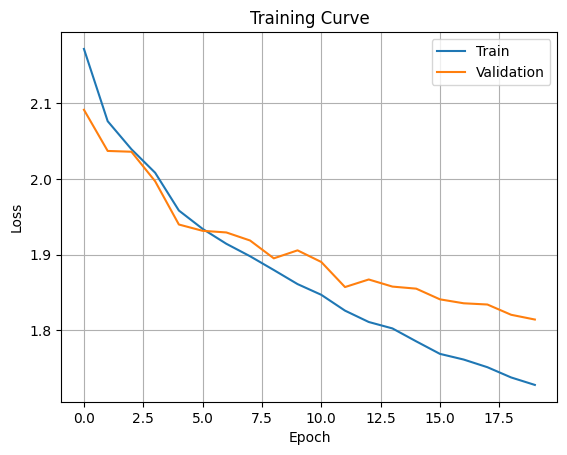

In [10]:
val_ratio = 0.1
val_size = int(len(target_data)*val_ratio)
train_size = len(target_data)-val_size

target_train,target_val = random_split(
    target_data,
    [train_size,val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    target_train,
    batch_size=128,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = DataLoader(
    target_val,
    batch_size=128,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=g
)

target_model = CNN(num_classes)

target_model = train_model(
    target_model,
    train_loader,
    val_loader,
    epochs=20,
    plot=True
)

# Split data for Target / Shadow

In [11]:
NUM_SHADOWS = 5

shadow_len = len(shadow_data)//NUM_SHADOWS

shadow_splits = random_split(
    shadow_data,
    [shadow_len]*NUM_SHADOWS,
    generator=torch.Generator().manual_seed(SEED)
)

# Collect Shadow Outputs

Attack Dataset Containers (per class)

In [12]:
attack_X = [[] for _ in range(num_classes)]
attack_y = [[] for _ in range(num_classes)]

In [13]:
def collect_outputs(model, loader, member):

    model.eval()

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)

            probs = model(x).cpu().numpy()
            labels = y.numpy()

            for i in range(len(probs)):

                c = labels[i]

                attack_X[c].append(probs[i])
                attack_y[c].append(member)

In [14]:
for i,shadow_subset in enumerate(shadow_splits):

    print("\nTraining shadow model",i)

    set_seed(SEED+i)

    val_ratio = 0.1
    val_size = int(len(shadow_subset)*val_ratio)
    train_size = len(shadow_subset)-val_size

    shadow_train,shadow_val = random_split(
        shadow_subset,
        [train_size,val_size],
        generator=torch.Generator().manual_seed(SEED+i)
    )

    train_loader = DataLoader(
        shadow_train,
        batch_size=128,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g
    )

    val_loader = DataLoader(
        shadow_val,
        batch_size=128,
        shuffle=False,
        worker_init_fn=seed_worker,
        generator=g
    )

    shadow_model = CNN(num_classes)

    shadow_model = train_model(
        shadow_model,
        train_loader,
        val_loader,
        epochs=20,
        plot=False
    )

    collect_outputs(shadow_model,train_loader,1)

    holdout,_ = random_split(
        testset,
        [len(shadow_subset),len(testset)-len(shadow_subset)],
        generator=torch.Generator().manual_seed(SEED+i)
    )

    holdout_loader = DataLoader(
        holdout,
        batch_size=128,
        shuffle=False,
        worker_init_fn=seed_worker,
        generator=g
    )

    collect_outputs(shadow_model,holdout_loader,0)


Training shadow model 0


Epoch 1/20 Train: 100%|██████████| 36/36 [00:00<00:00, 42.38it/s]


Train Loss: 2.2624 | Val Loss: 2.2181


Epoch 2/20 Train: 100%|██████████| 36/36 [00:00<00:00, 42.60it/s]


Train Loss: 2.1785 | Val Loss: 2.1583


...

Train Loss: 1.8998 | Val Loss: 2.0061


Epoch 19/20 Train: 100%|██████████| 36/36 [00:00<00:00, 41.25it/s]


Train Loss: 1.8842 | Val Loss: 2.0129


Epoch 20/20 Train: 100%|██████████| 36/36 [00:00<00:00, 41.08it/s]


Train Loss: 1.8844 | Val Loss: 2.0317


# Attack Model

In [15]:
class AttackMLP(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.fc1 = nn.Linear(input_size,64)
        self.fc2 = nn.Linear(64,2)

    def forward(self,x):

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [16]:
def train_attack_model(X,y,epochs=20):

    X = torch.tensor(X,dtype=torch.float32)
    y = torch.tensor(y,dtype=torch.long)

    dataset = TensorDataset(X,y)

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g
    )

    model = AttackMLP(num_classes).to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        running_loss = 0

        for x_batch,y_batch in loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            pred = model(x_batch)

            loss = criterion(pred,y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print("Attack Epoch",epoch+1,"Loss:",running_loss)

    return model

# Train Attack Models (one per class)

In [17]:
attack_models = []

for c in range(num_classes):

    print("\nTraining attack model for class",c)

    X = np.array(attack_X[c])
    y = np.array(attack_y[c])

    model = train_attack_model(X,y, epochs=50)

    attack_models.append(model)


Training attack model for class 0
Attack Epoch 1 Loss: 25.57478505373001
Attack Epoch 2 Loss: 25.48856484889984
Attack Epoch 3 Loss: 25.47124147415161
Attack Epoch 4 Loss: 25.47186905145645
Attack Epoch 5 Loss: 25.460944890975952
Attack Epoch 6 Loss: 25.45652484893799
Attack Epoch 7 Loss: 25.467066943645477
Attack Epoch 8 Loss: 25.449073433876038
Attack Epoch 9 Loss: 25.464303493499756
Attack Epoch 10 Loss: 25.44797170162201
Attack Epoch 11 Loss: 25.44534605741501
Attack Epoch 12 Loss: 25.447039365768433
Attack Epoch 13 Loss: 25.448177337646484
Attack Epoch 14 Loss: 25.448990762233734
Attack Epoch 15 Loss: 25.437148869037628
Attack Epoch 16 Loss: 25.447444260120392
Attack Epoch 17 Loss: 25.440177738666534
Attack Epoch 18 Loss: 25.43436849117279
Attack Epoch 19 Loss: 25.43517816066742
Attack Epoch 20 Loss: 25.430390298366547
Attack Epoch 21 Loss: 25.450131714344025
Attack Epoch 22 Loss: 25.428884088993073
Attack Epoch 23 Loss: 25.428909838199615
Attack Epoch 24 Loss: 25.433454632759094

# Attack Target Model

In [18]:
def get_attack_preds(loader):

    preds = []

    target_model.eval()

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)

            probs = target_model(x).cpu()

            for i in range(len(probs)):

                c = y[i].item()

                attack_model = attack_models[c]

                sample = probs[i].unsqueeze(0).to(device)

                out = attack_model(sample)

                pred = torch.argmax(out,dim=1).item()

                preds.append(pred)

    return np.array(preds)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

In [20]:
member_loader = DataLoader(target_data, batch_size=128)
nonmember_loader = DataLoader(testset, batch_size=128)

# Predictions
member_preds = get_attack_preds(member_loader)
nonmember_preds = get_attack_preds(nonmember_loader)

# True labels
member_true = np.ones(len(member_preds))
nonmember_true = np.zeros(len(nonmember_preds))

# Combine
y_true = np.concatenate([member_true, nonmember_true])
y_pred = np.concatenate([member_preds, nonmember_preds])

# Metrics
attack_accuracy = accuracy_score(y_true, y_pred)
attack_precision = precision_score(y_true, y_pred)
attack_recall = recall_score(y_true, y_pred)

print("\n===== Attack Metrics =====")
print(f"Accuracy  : {attack_accuracy:.4f}")
print(f"Precision : {attack_precision:.4f}")
print(f"Recall    : {attack_recall:.4f}")

print("\nDetailed report:")
print(classification_report(y_true, y_pred, target_names=["Non-member", "Member"]))


===== Attack Metrics =====
Accuracy  : 0.6347
Precision : 0.7515
Recall    : 0.7301

Detailed report:
              precision    recall  f1-score   support

  Non-member       0.37      0.40      0.38     10000
      Member       0.75      0.73      0.74     25000

    accuracy                           0.63     35000
   macro avg       0.56      0.56      0.56     35000
weighted avg       0.64      0.63      0.64     35000



In [21]:
nonmember_preds[10:30]

array([1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1])